<a href="https://colab.research.google.com/github/kxrrym03/Diabetes-Prediction/blob/main/Diabetes_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [2]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


In [3]:
df = pd.read_csv('diabetes.csv')
df.shape

(767, 9)

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
762,9,89,62,0,0,22.5,0.142,33,0
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [6]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 767 entries, 0 to 766
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               767 non-null    int64  
 1   Glucose                   767 non-null    int64  
 2   BloodPressure             767 non-null    int64  
 3   SkinThickness             767 non-null    int64  
 4   Insulin                   767 non-null    int64  
 5   BMI                       767 non-null    float64
 6   DiabetesPedigreeFunction  767 non-null    float64
 7   Age                       767 non-null    int64  
 8   Outcome                   767 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [10]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,767.000000,767.000000,767.000000,767.000000,767.000000,767.000000,767.000000,767.000000,767.000000
mean,3.848761,120.930900,69.104302,20.522816,79.903520,31.994654,0.472081,33.254237,0.349413
std,3.370207,31.977581,19.368410,15.958143,115.283105,7.889095,0.331496,11.762079,0.477096
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243500,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,32.000000,32.000000,0.374000,29.000000,0.000000
75%,6.000000,140.500000,80.000000,32.000000,127.500000,36.600000,0.626500,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [11]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [12]:
df.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


### Visualizations

array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

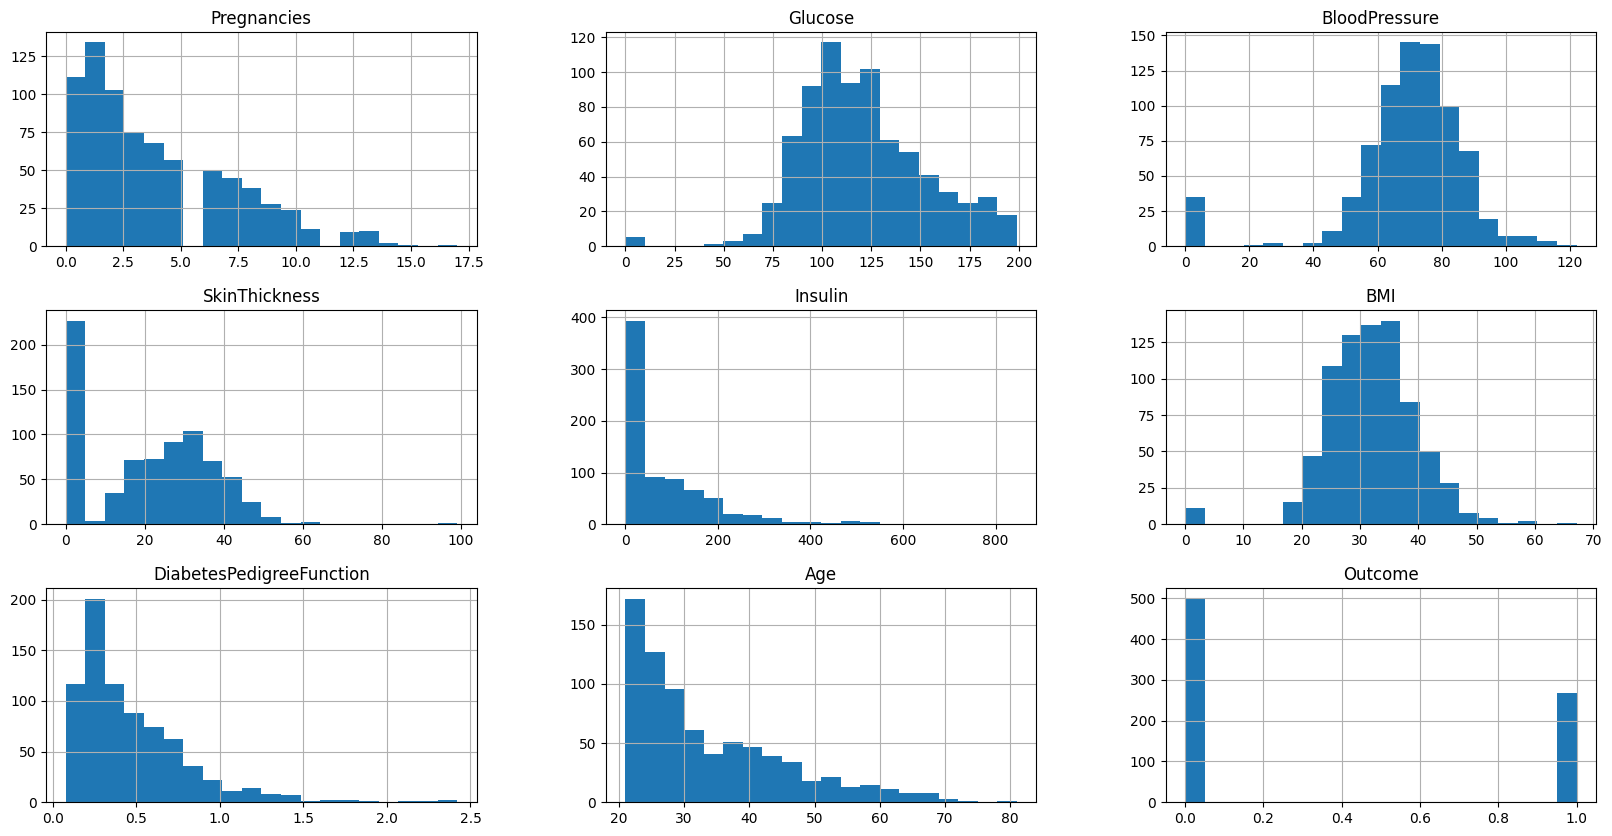

In [13]:
df.hist(bins=20, figsize=(20,10))

<Figure size 1600x2000 with 0 Axes>

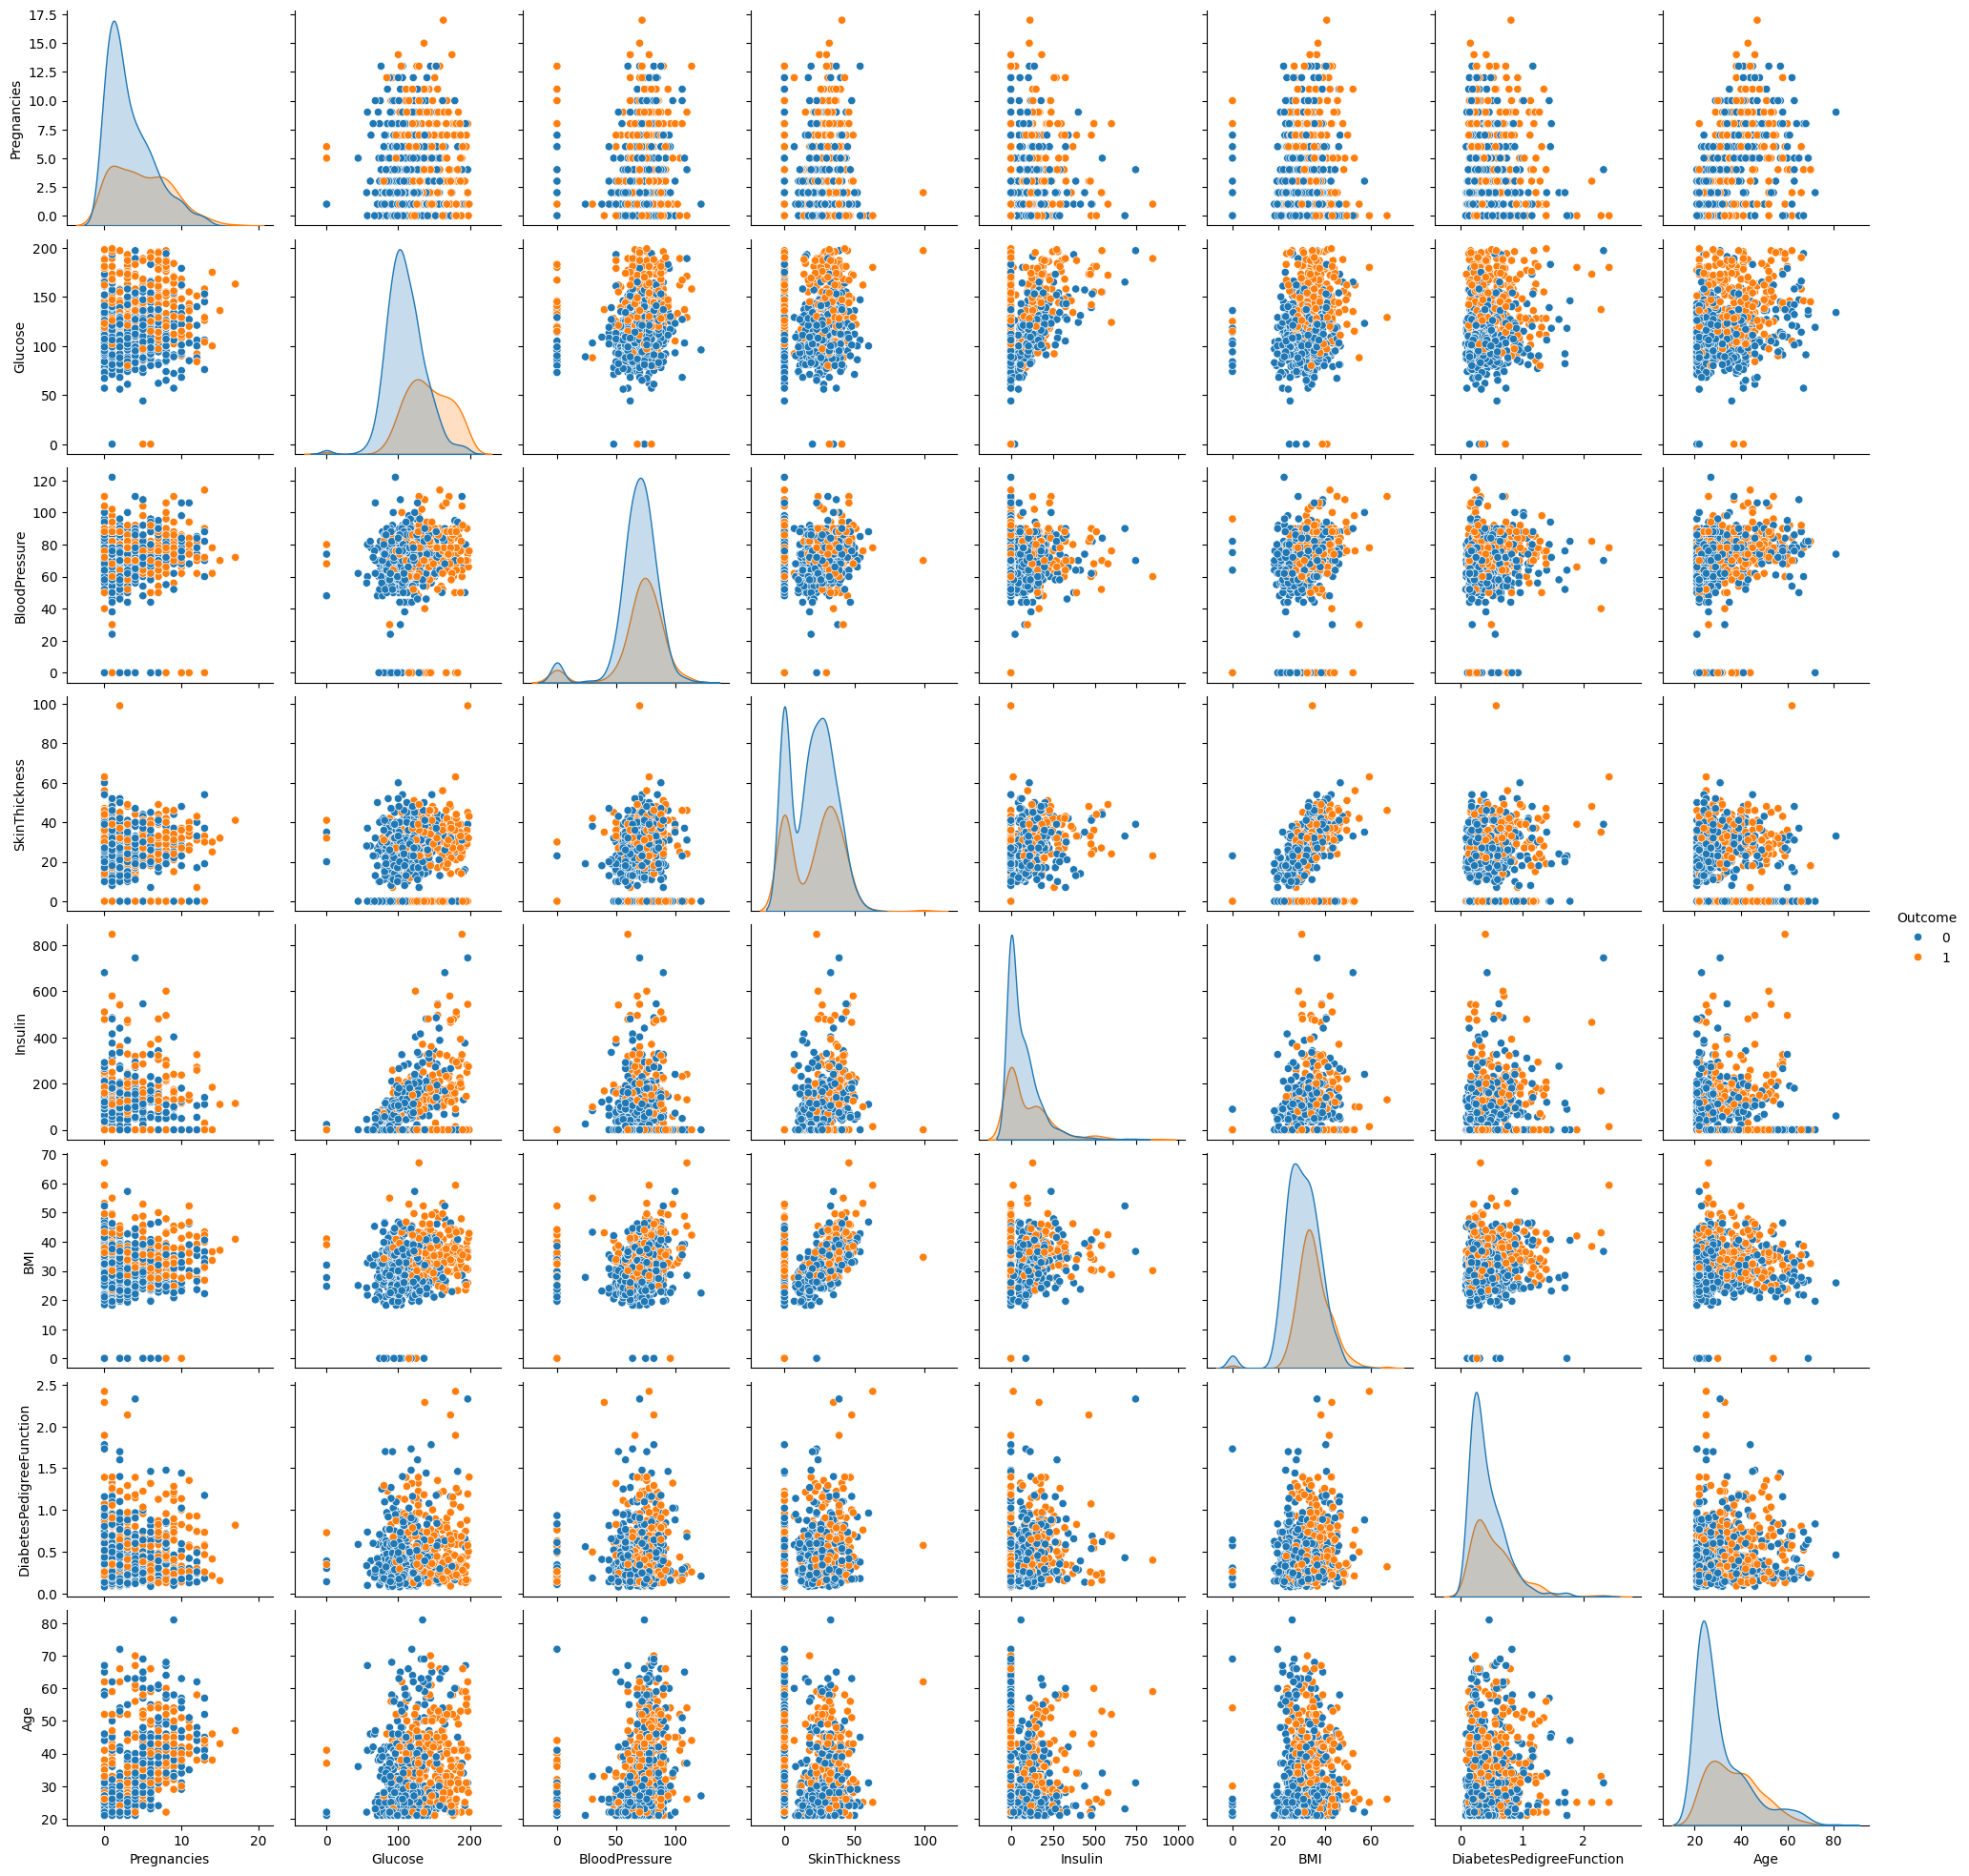

In [14]:
plt.figure(figsize=(16,20))
sns.pairplot(df, hue='Outcome', diag_kind='kde')

<Axes: >

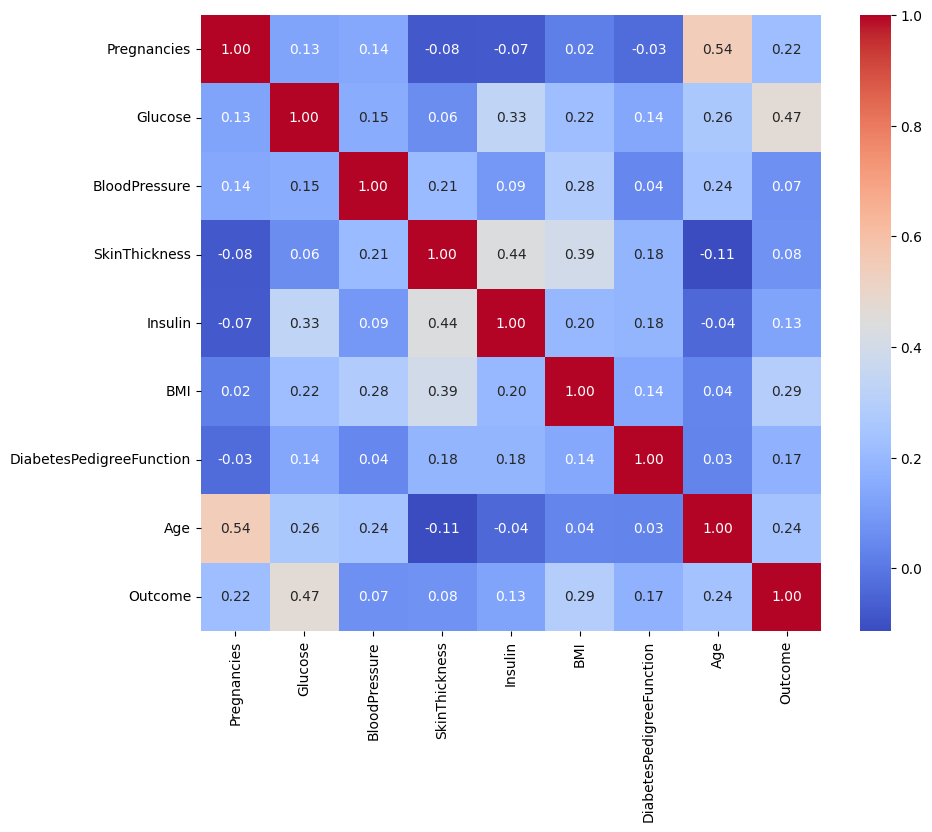

In [15]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True,fmt='.2f', cmap='coolwarm')

In [16]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, cross_val_predict, KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score, ConfusionMatrixDisplay, auc

In [17]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()

In [18]:
scale.fit(df.drop('Outcome', axis=1))

StandardScaler()

In [19]:
X = scale.transform(df.drop('Outcome', axis=1))
y = df['Outcome']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [23]:
# KNN
metrics = ['euclidean', 'manhattan', 'minkowski']
k_values = [3, 5, 7, 9]

results = []

for metric in metrics:
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric, weights='distance')
        cv = KFold(n_splits=5, shuffle=True, random_state=42)
        y_pred = cross_val_predict(knn, X_train, y_train, cv=cv)

        # Performance metrics
        accuracy_score_val = accuracy_score(y_train, y_pred)
        precision_score_val = precision_score(y_train, y_pred, average='binary')
        recall_score_val = recall_score(y_train, y_pred, average='binary')
        f1 = f1_score(y_train, y_pred, average='binary')

        results.append({
            'Metric': metric,
            'K': k,
            'Accuracy': accuracy_score_val,
            'Precision': precision_score_val,
            'Recall': recall_score_val,
            'F1 Score': f1
        })

results_df = pd.DataFrame(results)
print(results_df)
best_results = results_df.sort_values(by='F1 Score', ascending=False).head(1)
print("\nBest Results:")
print(best_results)

       Metric  K  Accuracy  Precision    Recall  F1 Score
0   euclidean  3  0.738806   0.633721  0.586022  0.608939
1   euclidean  5  0.729478   0.627329  0.543011  0.582133
2   euclidean  7  0.744403   0.654088  0.559140  0.602899
3   euclidean  9  0.746269   0.664474  0.543011  0.597633
4   manhattan  3  0.733209   0.625731  0.575269  0.599440
5   manhattan  5  0.740672   0.657718  0.526882  0.585075
6   manhattan  7  0.746269   0.673611  0.521505  0.587879
7   manhattan  9  0.740672   0.671533  0.494624  0.569659
8   minkowski  3  0.738806   0.633721  0.586022  0.608939
9   minkowski  5  0.729478   0.627329  0.543011  0.582133
10  minkowski  7  0.744403   0.654088  0.559140  0.602899
11  minkowski  9  0.746269   0.664474  0.543011  0.597633

Best Results:
      Metric  K  Accuracy  Precision    Recall  F1 Score
0  euclidean  3  0.738806   0.633721  0.586022  0.608939


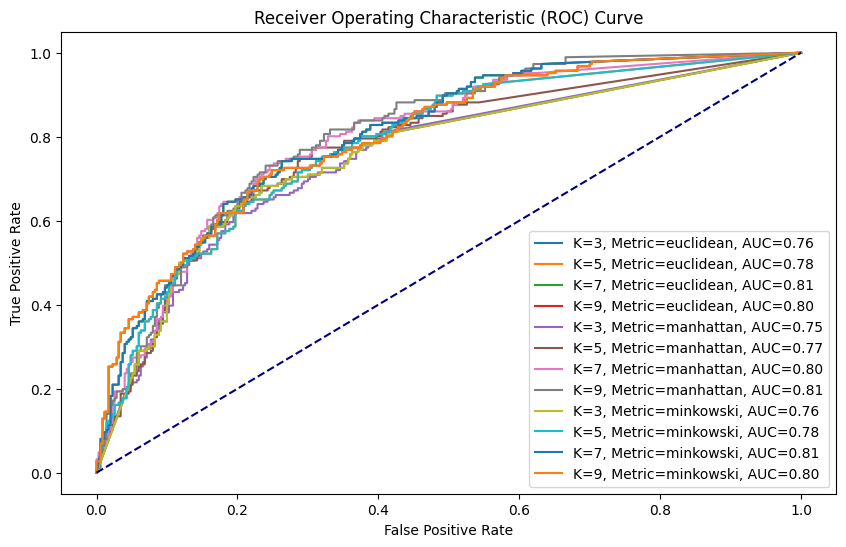

In [26]:
plt.figure(figsize=(10, 6))
for metric in metrics:
  for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric=metric, weights='distance')

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    knn.fit(X_train, y_train)

    y_pred = cross_val_predict(knn, X_train, y_train, cv=cv, method='predict')
    y_prob = cross_val_predict(knn, X_train, y_train, cv=cv, method='predict_proba')

    fpr, tpr, thresholds = roc_curve(y_train, y_prob[:, 1])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'K={k}, Metric={metric}, AUC={roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.show()

In [28]:
knn_best = KNeighborsClassifier(n_neighbors=3, metric='euclidean', weights='distance')
knn_best.fit(X_train, y_train)
y_pred_knn = knn_best.predict(X_test)

print("Classification Report for Best KNN Model:")
print(classification_report(y_test, y_pred_knn))

cm_knn = confusion_matrix(y_test, y_pred_knn)
print("\nConfusion Matrix for Best KNN Model:")
print(cm_knn)

Classification Report for Best KNN Model:
              precision    recall  f1-score   support

           0       0.78      0.77      0.77       149
           1       0.58      0.60      0.59        82

    accuracy                           0.71       231
   macro avg       0.68      0.68      0.68       231
weighted avg       0.71      0.71      0.71       231


Confusion Matrix for Best KNN Model:
[[114  35]
 [ 33  49]]


In [29]:
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("Classification Report for SVM Model (RBF Kernel):")
print(classification_report(y_test, y_pred_svm))

cm_svm = confusion_matrix(y_test, y_pred_svm)
print("\nConfusion Matrix for SVM Model (RBF Kernel):")
print(cm_svm)

Classification Report for SVM Model (RBF Kernel):
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       149
           1       0.68      0.65      0.66        82

    accuracy                           0.77       231
   macro avg       0.74      0.74      0.74       231
weighted avg       0.76      0.77      0.76       231


Confusion Matrix for SVM Model (RBF Kernel):
[[124  25]
 [ 29  53]]


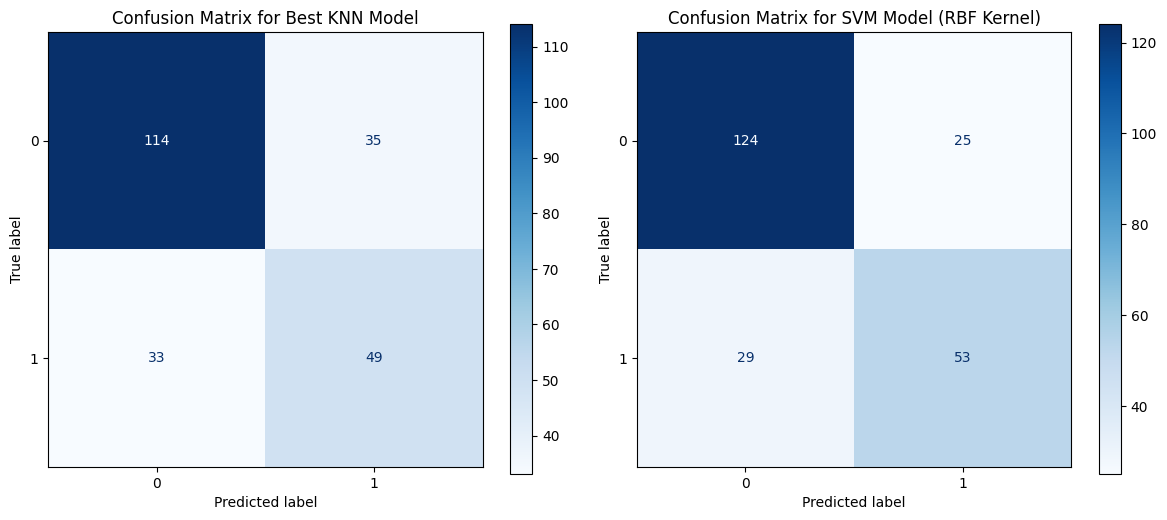

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plotting Confusion Matrix for KNN
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=[0, 1])
disp_knn.plot(cmap=plt.cm.Blues, ax=axes[0])
axes[0].set_title('Confusion Matrix for Best KNN Model')

# Plotting Confusion Matrix for SVM
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=[0, 1])
disp_svm.plot(cmap=plt.cm.Blues, ax=axes[1])
axes[1].set_title('Confusion Matrix for SVM Model (RBF Kernel)')

plt.tight_layout()
plt.show()

In [33]:
### Logistic Regression
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train, y_train)
y_pred_log_reg = log_reg_model.predict(X_test)

print("Classification Report for Logistic Regression Model (Rerun):")
print(classification_report(y_test, y_pred_log_reg))

cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
print("\nConfusion Matrix for Logistic Regression Model (Rerun):")
print(cm_log_reg)

Classification Report for Logistic Regression Model (Rerun):
              precision    recall  f1-score   support

           0       0.81      0.84      0.83       149
           1       0.69      0.65      0.67        82

    accuracy                           0.77       231
   macro avg       0.75      0.74      0.75       231
weighted avg       0.77      0.77      0.77       231


Confusion Matrix for Logistic Regression Model (Rerun):
[[125  24]
 [ 29  53]]


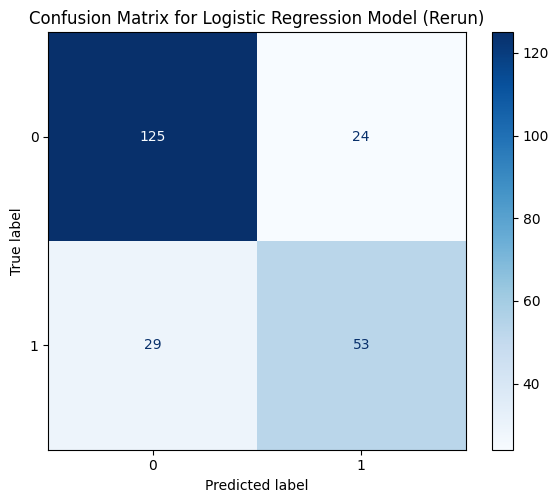

In [34]:
fig, ax = plt.subplots(figsize=(6, 5))
disp_log_reg = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg, display_labels=[0, 1])
disp_log_reg.plot(cmap=plt.cm.Blues, ax=ax)
ax.set_title('Confusion Matrix for Logistic Regression Model (Rerun)')
plt.tight_layout()
plt.show()

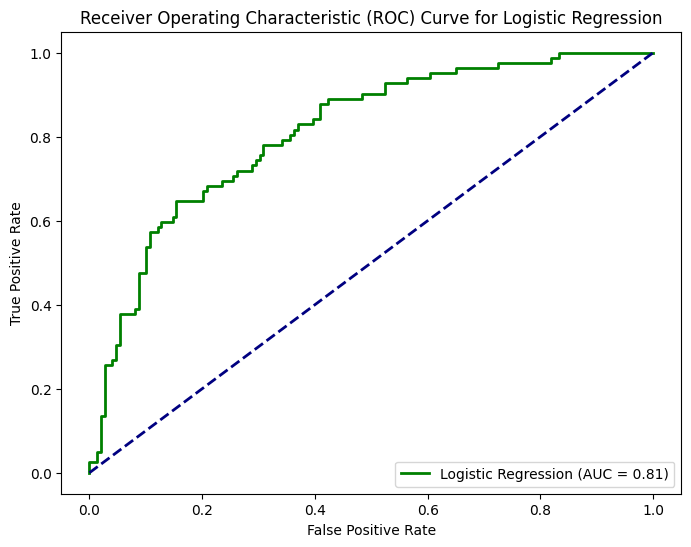

In [35]:
y_prob_log_reg = log_reg_model.predict_proba(X_test)[:, 1]
fpr_log_reg, tpr_log_reg, thresholds_log_reg = roc_curve(y_test, y_prob_log_reg)
roc_auc_log_reg = auc(fpr_log_reg, tpr_log_reg)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log_reg, tpr_log_reg, color='green', lw=2, label=f'Logistic Regression (AUC = {roc_auc_log_reg:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Logistic Regression')
plt.legend(loc='lower right')
plt.show()